# visualization.network-bacteria


In this notebook, we will create networks that allow us to study the interactions between bacteria and hosts. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import igraph  as ig
import networkx as nx
import random
habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'

## Bacteria - host weighted matrix

In [3]:
metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")


In [5]:
bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)
bacteria_host = bacteria_hits.value_counts(
    ['host_taxon', 'scientific_name', 'habitat']
).reset_index()
bacteria_host['type'] = 'bacteria'
bacteria_host = bacteria_host[['host_taxon', 'scientific_name', 'habitat', 'type', 'count']].copy().rename(columns={'scientific_name': 'scientific_name'}).copy()
bacteria_host

,host_taxon,scientific_name,habitat,type,count
0,Convolvulus arvensis,Rhodococcoides fascians,Edge,bacteria,3
1,Cucumis melo,Bradyrhizobium elkanii,Crop,bacteria,3
2,Amaranthus sp,Arthrobacter sp. Leaf234,Edge,bacteria,2
3,Galium verum,Pseudomonas lutea,Oak,bacteria,2
4,Anchusa undulata,Chryseobacterium sp. Leaf201,Wasteland,bacteria,2
...,...,...,...,...,...
411,Convolvulus arvensis,Rhizobium leguminosarum,Crop,bacteria,1
412,Convolvulus arvensis,Pseudomonas sp. Leaf127,Edge,bacteria,1
413,Convolvulus arvensis,Pseudomonas putida,Crop,bacteria,1
414,Convolvulus arvensis,Pseudomonas oryzihabitans,Crop,bacteria,1


In [6]:
organism_host = pd.concat([bacteria_host])
organism_host

,host_taxon,scientific_name,habitat,type,count
0,Convolvulus arvensis,Rhodococcoides fascians,Edge,bacteria,3
1,Cucumis melo,Bradyrhizobium elkanii,Crop,bacteria,3
2,Amaranthus sp,Arthrobacter sp. Leaf234,Edge,bacteria,2
3,Galium verum,Pseudomonas lutea,Oak,bacteria,2
4,Anchusa undulata,Chryseobacterium sp. Leaf201,Wasteland,bacteria,2
...,...,...,...,...,...
411,Convolvulus arvensis,Rhizobium leguminosarum,Crop,bacteria,1
412,Convolvulus arvensis,Pseudomonas sp. Leaf127,Edge,bacteria,1
413,Convolvulus arvensis,Pseudomonas putida,Crop,bacteria,1
414,Convolvulus arvensis,Pseudomonas oryzihabitans,Crop,bacteria,1


### Adjacency matrix

In [7]:
organism_host_pvt = organism_host.groupby(['host_taxon', 'scientific_name'], as_index=False)['count'].sum().pivot(index='host_taxon', columns='scientific_name', values='count').fillna(0.0)
organism_host_pvt

scientific_name,Achromobacter xylosoxidans,Acidovorax sp. Leaf160,Acidovorax sp. Leaf78,Acinetobacter baumannii,Acinetobacter pittii,Agrobacterium rubi,Agrobacterium tumefaciens,Agrobacterium vitis,Angustibacter sp. Root456,Arthrobacter sp. Leaf234,...,Sphingomonas sp. Leaf28,Sphingomonas sp. Leaf339,Sphingomonas taxi,Stenotrophomonas maltophilia,Streptomyces griseorubiginosus,Stutzerimonas stutzeri,Variovorax paradoxus,Xanthomonas campestris,Xaviernesmea rhizosphaerae,Xylophilus sp. Leaf220
host_taxon,,,,,,,,,,,,,,,,,,,,,
Amaranthus sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Anacyclus clavatus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Anchusa undulata,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andryala arenaria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Anthriscus caucalis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tragopogon sp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Trifolium tomentosum,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Verbascum sinuatum,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
organism_host_pvt.to_csv("scratch/adjmat.bact.weighted.csv", sep=";")

### Multigraph

In [9]:
M = nx.MultiGraph()
for _, row in organism_host.drop_duplicates(subset=['scientific_name', 'type'], keep='first').iterrows():
    M.add_node(row.scientific_name, kingdom=row.type, role=row.type, scientific_name=row.scientific_name)

for _, row in organism_host.drop_duplicates(['host_taxon'], keep='first').iterrows():
    M.add_node(row.host_taxon, kingdom='host', role='host', scientific_name=row.host_taxon)

for _, row in organism_host.iterrows():
    M.add_edge(row.host_taxon, row.scientific_name, weight=row['count'], habitat=row['habitat'])

nx.write_graphml(M, "output/network.bact-host.multigraph.graphml")

### Visualization

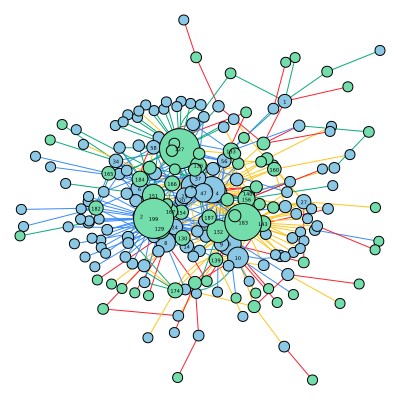

In [10]:
role_palette = {
    'host': "#73deac",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}

g = ig.read("output/network.bact-host.multigraph.graphml", format='graphml')
edge_colors = [habitat_palette[edge['habitat']] for edge in g.es]
node_colors = [role_palette[vertex['role']] for vertex in g.vs]
degrees = g.degree()
min_degree = min(degrees)
max_degree = max(degrees)
normalized_sizes = [10 + 30 * (degree - min_degree) / (max_degree - min_degree) for degree in degrees]
degree_threshold = 10

degree_threshold = 5
labels = [
    dict(num_label=str(i), label=str(v['scientific_name'])) if degree > degree_threshold else dict(num_label="", label=str("")) for i, (v, degree) in enumerate(zip(g.vs, degrees))
]
labels = pd.DataFrame.from_records(labels)

random.seed(124)
layout = g.layout("kk")
ig.plot(
    g, layout=layout, edge_color=edge_colors, vertex_color=node_colors, 
    vertex_size=normalized_sizes, 
    target="figures/bact-host.multigraph.kk-layout.svg", 
    vertex_label=labels['num_label'], vertex_label_size=5,
    bbox=(400, 400)
)

In [11]:
modules = pd.read_csv("scratch/modules.bact.weighted.csv", sep='\t').query('type == "row"')
# modules['value'] = modules['value'].apply(lambda x: x[1:])
modules

,index,type,value
0,1,row,Aphyllanthes monspeliensis
1,1,row,Artemisia herba alba
2,1,row,Brassica oleracea
3,1,row,Chenopodium album
4,1,row,Cucumis melo
...,...,...,...
171,6,row,Eruca vesicaria
172,6,row,Hirschfeldia incana
173,6,row,Klasea pinnatifida
174,6,row,Quercus coccifera


In [12]:
modules

,index,type,value
0,1,row,Aphyllanthes monspeliensis
1,1,row,Artemisia herba alba
2,1,row,Brassica oleracea
3,1,row,Chenopodium album
4,1,row,Cucumis melo
...,...,...,...
171,6,row,Eruca vesicaria
172,6,row,Hirschfeldia incana
173,6,row,Klasea pinnatifida
174,6,row,Quercus coccifera


In [13]:
host_habitat = organism_host[['host_taxon', 'habitat']].drop_duplicates()
host_habitat

,host_taxon,habitat
0,Convolvulus arvensis,Edge
1,Cucumis melo,Crop
2,Amaranthus sp,Edge
3,Galium verum,Oak
4,Anchusa undulata,Wasteland
...,...,...
343,Datura stramonium,Crop
348,Cyperus longus,Crop
366,Convolvulus arvensis,Crop
369,Convolvulus arvensis,Wasteland


In [14]:
cont_table = pd.merge(
    modules, host_habitat, left_on='value', right_on='host_taxon'
).value_counts(
    ['index', 'habitat']
).reset_index().pivot(
    index='index', columns='habitat', values='count'
).fillna(0).astype(int)
cont_table

habitat,Crop,Edge,Oak,Wasteland
index,,,,
1,5,1,6,3
2,1,4,6,7
3,3,8,4,9
4,4,6,3,2
5,3,4,5,9
6,2,3,1,1


In [15]:
contingency_test = stats.chi2_contingency(cont_table)
print(f"p-value = {contingency_test.pvalue:8.6e}")
print(f"stat    = {contingency_test.statistic:8.6e}")
print(f"dof     = {contingency_test.dof:8d}")

p-value = 2.877349e-01
stat    = 1.753795e+01
dof     =       15


In [16]:
contingency_test.pvalue

0.2877348589506307

In [17]:
modules.value_counts(['index'])

index
3        17
5        17
2        13
1        12
4         9
6         7
Name: count, dtype: int64